# 21. Contract mapper diagnostics

Проверка новой шкалы `z_contract` и ручного интерпретируемого mapper-а. Этот ноутбук не обучает модель, а показывает, что означает `z = 0.5 / 1 / 1.5 / 2` в dB.

In [1]:

from personalization.plotting import use_article_style
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
TABLES_DIR = OUTPUT_DIR / "tables"
for p in [FIGURES_DIR, METRICS_DIR, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from personalization.state import FEATURE_NAMES_8D
from personalization.contract_space import (
    DEFAULT_CONTRACT_SCALE,
    CONTRACT_ARCHETYPES_8D,
    archetype_table,
    contract_scale_table,
    make_axis_sweep_contract,
    z_contract_series,
)
from personalization.contract_mapper import InterpretableContractMapper8D, FREQS_23_DEFAULT
from personalization.contract_metrics import curve_metrics, mapped_pair_metrics, mapped_distance_to_target


def plot_eq_curves(curves, freqs=FREQS_23_DEFAULT, title=None):
    fig, ax = plt.subplots(figsize=(13, 5))
    for label, curve in curves.items():
        ax.plot(freqs, curve, marker="o", linewidth=1.6, label=label)
    ax.axhline(0, linewidth=1, alpha=0.35)
    ax.set_xscale("log")
    ax.set_xticks(freqs)
    ax.set_xticklabels([f"{f:g}" for f in freqs], rotation=45, ha="right")
    ax.set_xlabel("Frequency, Hz")
    ax.set_ylabel("Gain, dB")
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    plt.tight_layout()
    return fig, ax


def savefig(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("saved:", path)

use_article_style()



## Contract scale

`z8_scaled_vector` в новых mapper/personalization-экспериментах трактуем как `z_contract`, а не как percentile-scale.

In [2]:
contract_scale_table(DEFAULT_CONTRACT_SCALE)

,feature,z_0,raw_db_per_z_unit,raw_db_at_z_1,raw_db_at_z_2
0,sub_bass,0.0,8.0,8.0,16.0
1,bass,0.0,7.0,7.0,14.0
2,lowmid,0.0,3.0,3.0,6.0
3,warmth,0.0,3.0,3.0,6.0
4,presence,0.0,2.5,2.5,5.0
5,clarity,0.0,3.5,3.5,7.0
6,air,0.0,6.0,6.0,12.0
7,brightness,0.0,4.0,4.0,8.0


## Axis sweeps

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_contract_mapper_sweep_sub_bass.png


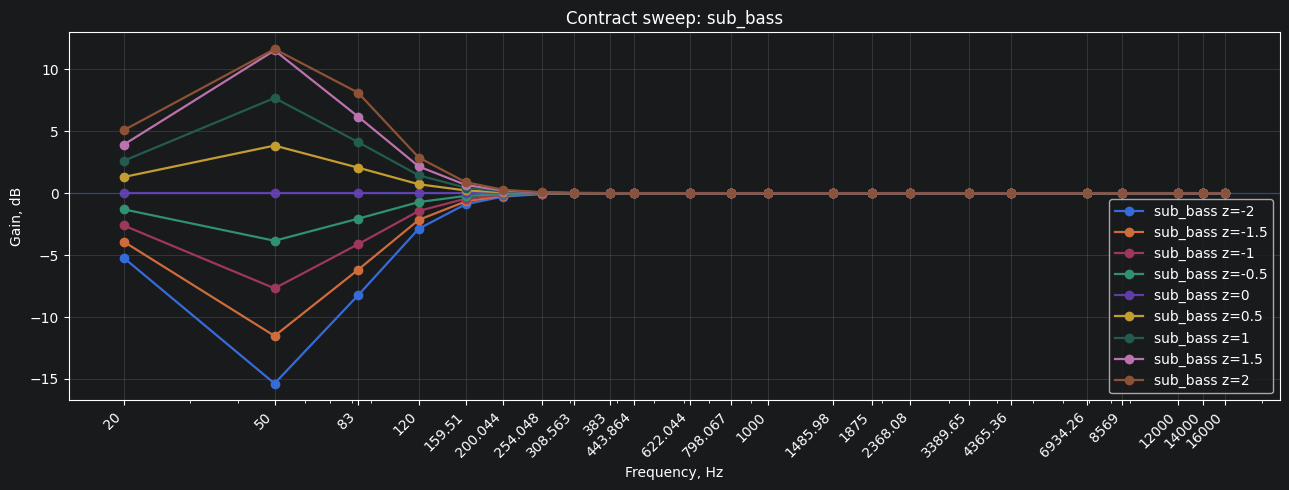

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_contract_mapper_sweep_bass.png


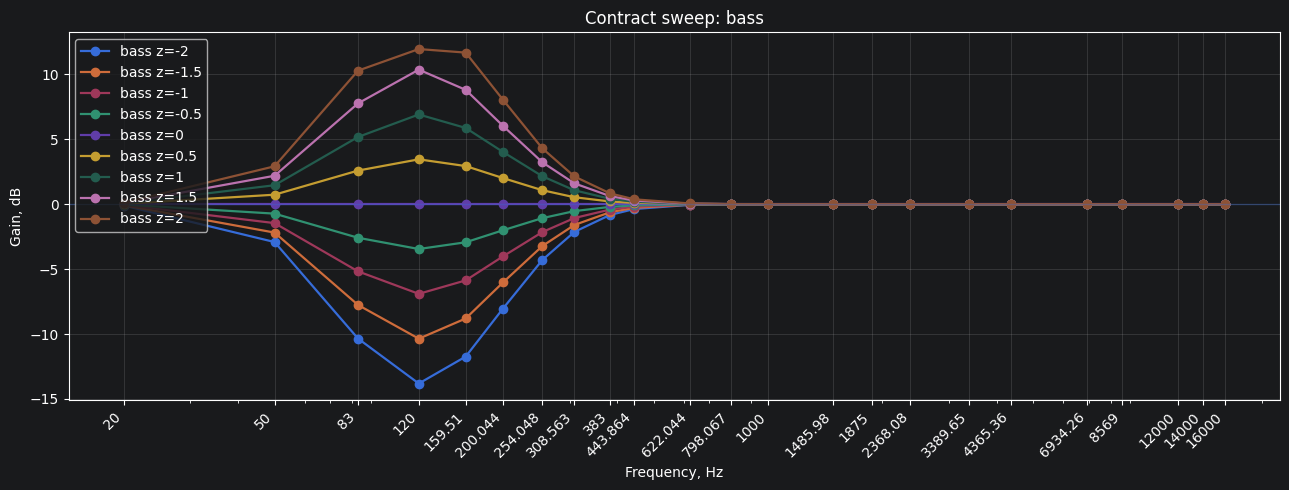

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_contract_mapper_sweep_air.png


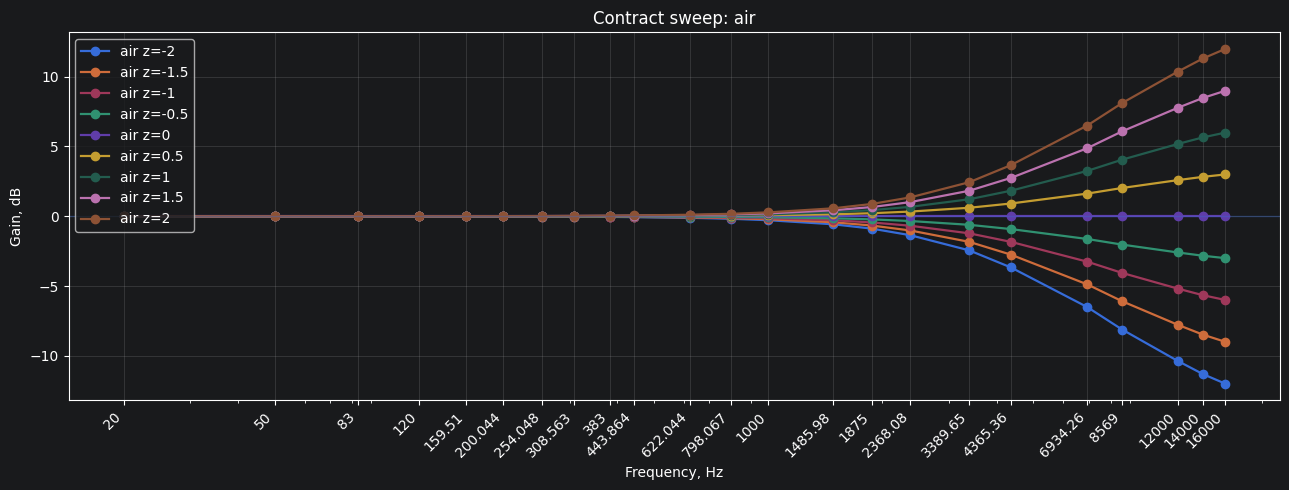

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_contract_mapper_sweep_brightness.png


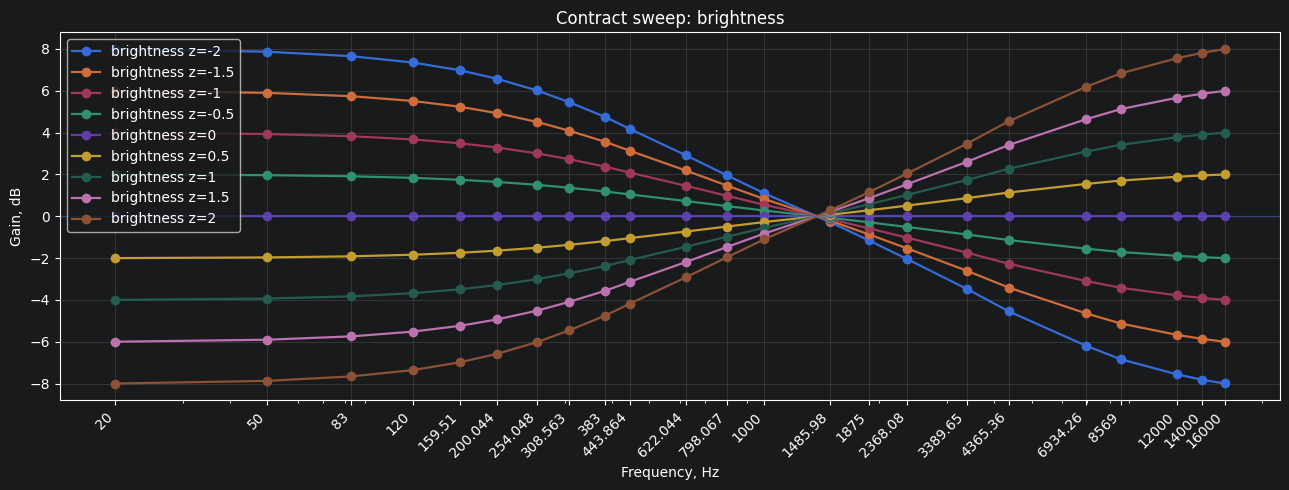

In [3]:
mapper = InterpretableContractMapper8D(freqs_hz=FREQS_23_DEFAULT, safety=True)
values = [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0]

for feature in ["sub_bass", "bass", "air", "brightness"]:
    X = make_axis_sweep_contract(feature, values)
    Y = mapper.map_batch(X)
    curves = {f"{feature} z={v:g}": y for v, y in zip(values, Y)}
    plot_eq_curves(curves, title=f"Contract sweep: {feature}")
    savefig(f"v6_contract_mapper_sweep_{feature}.png")
    plt.show()

## Contract archetypes

In [4]:
archetype_table()

,archetype,sub_bass,bass,lowmid,warmth,presence,clarity,air,brightness
0,neutral,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,basshead,1.65,1.45,-0.25,0.15,-0.20,0.10,0.25,-0.35
2,warm_dark,0.65,0.80,0.50,1.15,-0.55,-0.65,-0.75,-1.10
3,bright_air,-0.35,-0.25,-0.35,-0.20,0.55,1.10,1.55,1.35
4,v_shape,1.15,0.95,-0.85,-0.45,0.35,0.75,1.00,0.65
5,vocal_clear,-0.25,-0.15,-0.30,0.10,1.10,0.95,0.45,0.35
6,soft_warm,0.30,0.40,0.35,0.85,-0.10,-0.15,0.05,-0.20
7,lowmid_cut,0.45,0.30,-1.25,-0.65,0.35,0.45,0.30,0.25


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_contract_mapper_archetypes.png


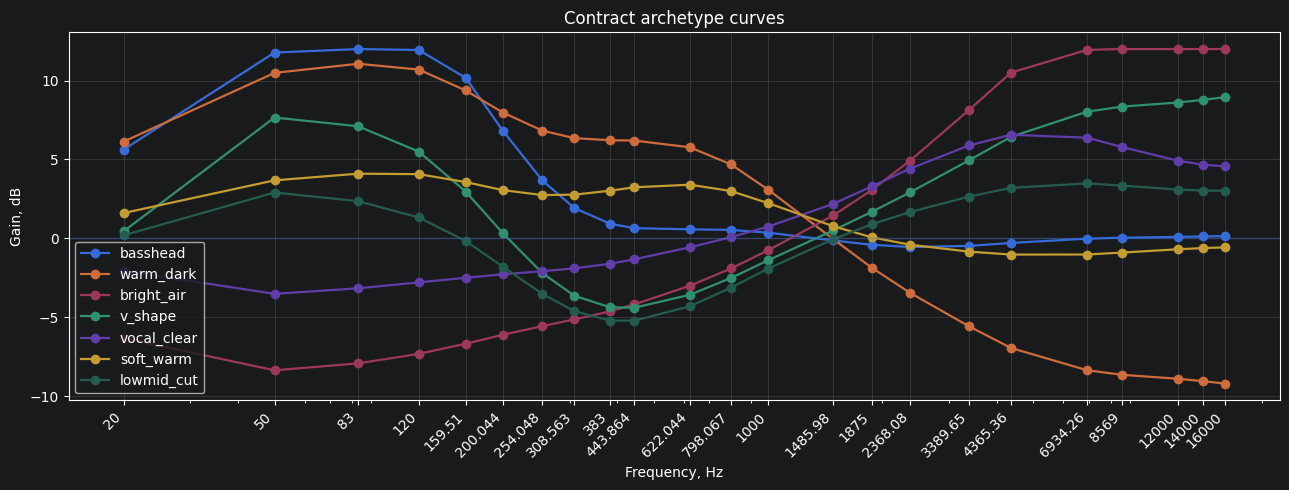

In [5]:
curves = {}
for name, z in CONTRACT_ARCHETYPES_8D.items():
    if name == "neutral":
        continue
    curves[name] = mapper.map_one(z)

plot_eq_curves(curves, title="Contract archetype curves")
savefig("v6_contract_mapper_archetypes.png")
plt.show()

## Curve strength diagnostics

In [6]:
rows = []
for name, z in CONTRACT_ARCHETYPES_8D.items():
    curve = mapper.map_one(z)
    m = curve_metrics(curve)
    rows.append({
        "archetype": name,
        "max_abs_db": m.max_abs_db,
        "mean_abs_db": m.mean_abs_db,
        "rms_db": m.rms_db,
        "smoothness": m.smoothness,
    })

stats = pd.DataFrame(rows).sort_values("max_abs_db", ascending=False)
stats.to_csv(TABLES_DIR / "v6_contract_mapper_archetype_curve_stats.csv", index=False)
stats

,archetype,max_abs_db,mean_abs_db,rms_db,smoothness
1,basshead,12.000000,3.009790,5.220560,1.450994
3,bright_air,12.000000,6.781523,7.659594,0.806773
2,warm_dark,11.066725,6.824353,7.373631,1.068001
4,v_shape,8.948823,4.578288,5.394027,1.812747
5,vocal_clear,6.566871,3.187408,3.690144,0.550724
7,lowmid_cut,5.215507,2.656268,3.030217,0.841028
6,soft_warm,4.098800,2.060417,2.444069,0.492469
0,neutral,0.000000,0.000000,0.000000,0.000000
